# PCA Factor Analysis for Yield Curves

This notebook demonstrates PCA-based factor decomposition for yield curve analysis.

**Key Concepts**:
- PC1 (Level): Parallel shifts (~85-90% of variance)
- PC2 (Slope): Short vs long rates (~8-12% of variance)
- PC3 (Curvature): Butterfly movements (~1-3% of variance)

**Applications**:
- P&L attribution
- Factor-based hedging
- Relative value trading
- Risk management

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import date, timedelta

from Risk.FactorDecomposition import PCAFactorModel
from Signals.PCAFactorSignal import PCAFactorSignal

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate Synthetic Yield Curve Data

For demonstration, we'll create synthetic yield curve movements with realistic factor structure.

In [2]:
# Create 1 year of daily data
n_days = 252
dates = [date(2024, 1, 1) + timedelta(days=i) for i in range(n_days)]
tenors = ["3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

# Generate factors with realistic properties
level_factor = np.random.randn(n_days) * 0.05  # 5bp volatility
slope_factor = np.random.randn(n_days) * 0.03  # 3bp volatility
curve_factor = np.random.randn(n_days) * 0.01  # 1bp volatility

# Create yield curve changes
changes_data = {"date": dates}

for i, tenor in enumerate(tenors):
    # Weight factors by maturity
    maturity_weight = i / len(tenors)  # 0 to 1
    
    # Level: equal weight across curve
    level_component = level_factor * 1.0
    
    # Slope: longer maturities move more
    slope_component = slope_factor * (maturity_weight - 0.5) * 2
    
    # Curvature: butterfly shape
    curve_component = curve_factor * (-4 * (maturity_weight - 0.5)**2 + 1)
    
    changes_data[tenor] = (level_component + slope_component + curve_component)

changes_df = pl.DataFrame(changes_data)

print(f"Created {len(dates)} days of yield curve changes")
print(f"Tenors: {tenors}")
print("\nFirst 5 rows:")
print(changes_df.head())

Created 252 days of yield curve changes
Tenors: ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

First 5 rows:
shape: (5, 11)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬──────────┬──────────┬───────────┐
│ date       ┆ 3M        ┆ 6M        ┆ 1Y        ┆ … ┆ 7Y        ┆ 10Y      ┆ 20Y      ┆ 30Y       │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪══════════╪═══════════╡
│ 2024-01-01 ┆ -0.038829 ┆ -0.028438 ┆ -0.017527 ┆ … ┆ 0.031322  ┆ 0.044836 ┆ 0.05887  ┆ 0.073425  │
│ 2024-01-02 ┆ -0.037887 ┆ -0.033446 ┆ -0.028615 ┆ … ┆ -0.005395 ┆ 0.001385 ┆ 0.008554 ┆ 0.016112  │
│ 2024-01-03 ┆ 0.077966  ┆ 0.066717  ┆ 0.055942  ┆ … ┆ 0.017581  ┆ 0.009176 ┆ 0.001244 ┆ -0.006213 │
│ 2024-01-04 ┆ 0.090679  ┆ 0.084663  ┆ 0.079338  ┆

## 2. Fit PCA Factor Model

Extract the principal components from yield curve changes.

In [3]:
# Fit PCA model
model = PCAFactorModel(n_components=3)
model.fit(changes_df, date_column="date")

# Print summary
print(model.summary())

PCA Factor Model Summary
Number of components: 3
Number of tenors: 10
Tenors: 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y
Training samples: 252
Date range: 2024-01-01 to 2024-09-08

Explained Variance:
  Level (PC1): 88.98%
  Slope (PC2): 10.73%
  Curvature (PC3): 0.29%
  Cumulative: 100.00%

Factor Loadings:
  Level (PC1):
    3M: +0.3164
    6M: +0.3195
    1Y: +0.3214
    2Y: +0.3221
    3Y: +0.3217
    5Y: +0.3201
    7Y: +0.3173
    10Y: +0.3133
    20Y: +0.3081
    30Y: +0.3018
  Slope (PC2):
    3M: -0.4884
    6M: -0.3799
    1Y: -0.2709
    2Y: -0.1615
    3Y: -0.0518
    5Y: +0.0582
    7Y: +0.1687
    10Y: +0.2795
    20Y: +0.3907
    30Y: +0.5023
  Curvature (PC3):
    3M: +0.5287
    6M: +0.1801
    1Y: -0.0815
    2Y: -0.2561
    3Y: -0.3436
    5Y: -0.3441
    7Y: -0.2576
    10Y: -0.0840
    20Y: +0.1766
    30Y: +0.5242


## 3. Visualize Factor Loadings

Plot how each factor affects different maturities.

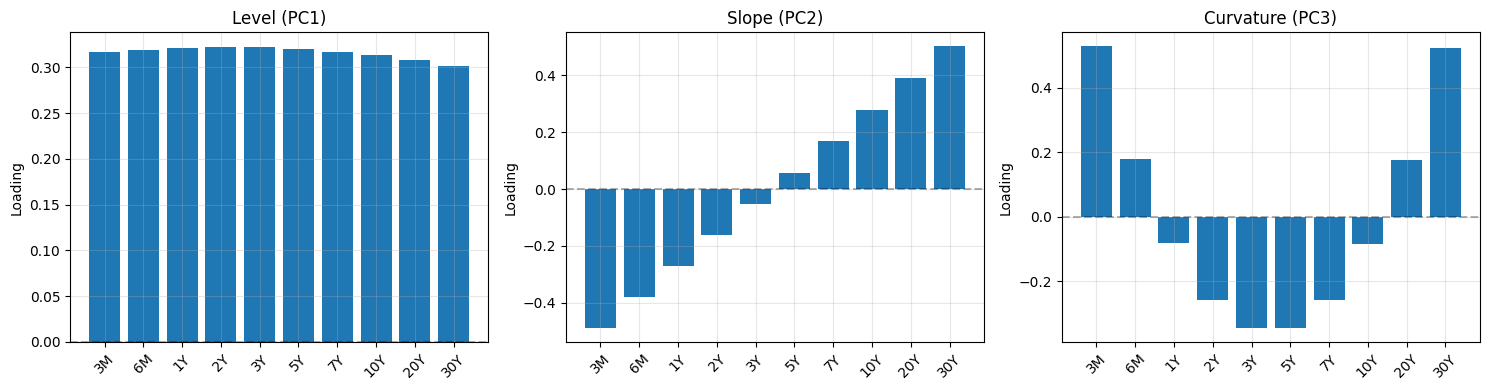


Interpretation:
- Level: All loadings have same sign (parallel shift)
- Slope: Sign changes once (short vs long)
- Curvature: Sign changes twice (wings vs belly)


In [4]:
# Get loadings
loadings = model.get_loadings()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
factor_names = ["Level (PC1)", "Slope (PC2)", "Curvature (PC3)"]

for i, (ax, name) in enumerate(zip(axes, factor_names)):
    ax.bar(range(len(tenors)), loadings[i, :])
    ax.set_xticks(range(len(tenors)))
    ax.set_xticklabels(tenors, rotation=45)
    ax.set_title(name)
    ax.set_ylabel("Loading")
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Level: All loadings have same sign (parallel shift)")
print("- Slope: Sign changes once (short vs long)")
print("- Curvature: Sign changes twice (wings vs belly)")

## 4. Factor Time Series

Plot factor values over time.

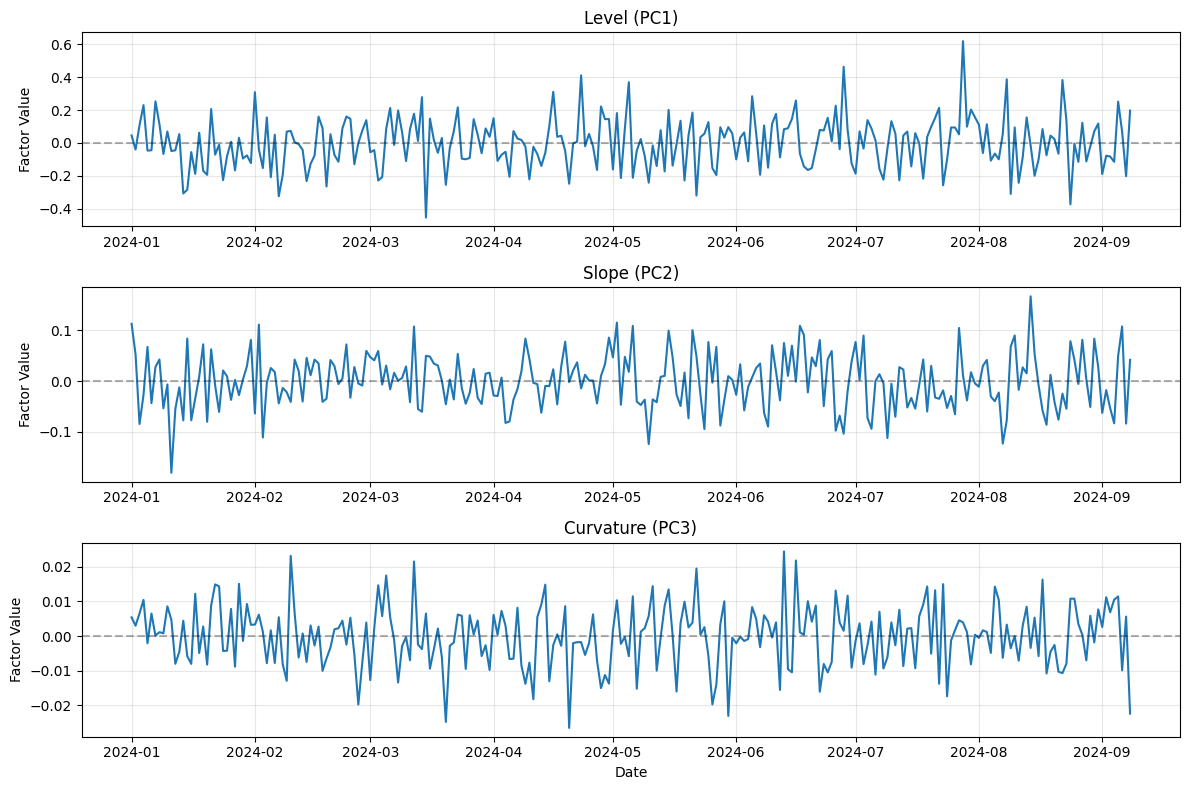

In [5]:
# Extract factor time series
factor_scores = model.factor_scores

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for i, (ax, name) in enumerate(zip(axes, factor_names)):
    ax.plot(dates, factor_scores[:, i])
    ax.set_title(name)
    ax.set_ylabel("Factor Value")
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 5. Factor-Based Hedging Example

Calculate hedge ratios to neutralize factor exposures.

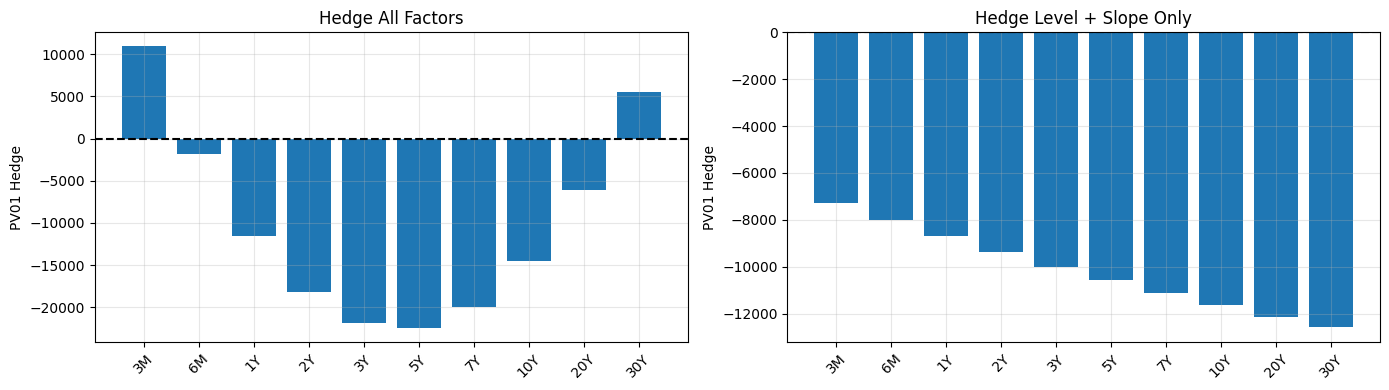


Hedge Ratios (Level + Slope):
  3M: -7,282
  6M: -8,014
  1Y: -8,710
  2Y: -9,370
  3Y: -9,995
  5Y: -10,584
  7Y: -11,137
  10Y: -11,655
  20Y: -12,137
  30Y: -12,584


In [6]:
# Example: Portfolio long 100k PV01 in 5Y
portfolio_pv01 = {
    "3M": 0,
    "6M": 0,
    "1Y": 0,
    "2Y": 0,
    "3Y": 0,
    "5Y": 100_000,
    "7Y": 0,
    "10Y": 0,
    "20Y": 0,
    "30Y": 0,
}

# Calculate hedges to neutralize all factors
hedges_all = model.factor_hedge_ratios(portfolio_pv01)

# Calculate hedges to neutralize only level and slope
hedges_level_slope = model.factor_hedge_ratios(portfolio_pv01, factors_to_hedge=[0, 1])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All factors hedged
axes[0].bar(range(len(tenors)), [hedges_all[t] for t in tenors])
axes[0].set_xticks(range(len(tenors)))
axes[0].set_xticklabels(tenors, rotation=45)
axes[0].set_title("Hedge All Factors")
axes[0].set_ylabel("PV01 Hedge")
axes[0].axhline(y=0, color='k', linestyle='--')
axes[0].grid(True, alpha=0.3)

# Level + slope hedged
axes[1].bar(range(len(tenors)), [hedges_level_slope[t] for t in tenors])
axes[1].set_xticks(range(len(tenors)))
axes[1].set_xticklabels(tenors, rotation=45)
axes[1].set_title("Hedge Level + Slope Only")
axes[1].set_ylabel("PV01 Hedge")
axes[1].axhline(y=0, color='k', linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHedge Ratios (Level + Slope):")
for tenor, hedge in hedges_level_slope.items():
    if abs(hedge) > 1000:
        print(f"  {tenor}: {hedge:,.0f}")

## 6. PCA Factor Signal

Use factor analysis to generate trading signals.

Error on 2024-06-30: Date 2024-06-30 not in training data


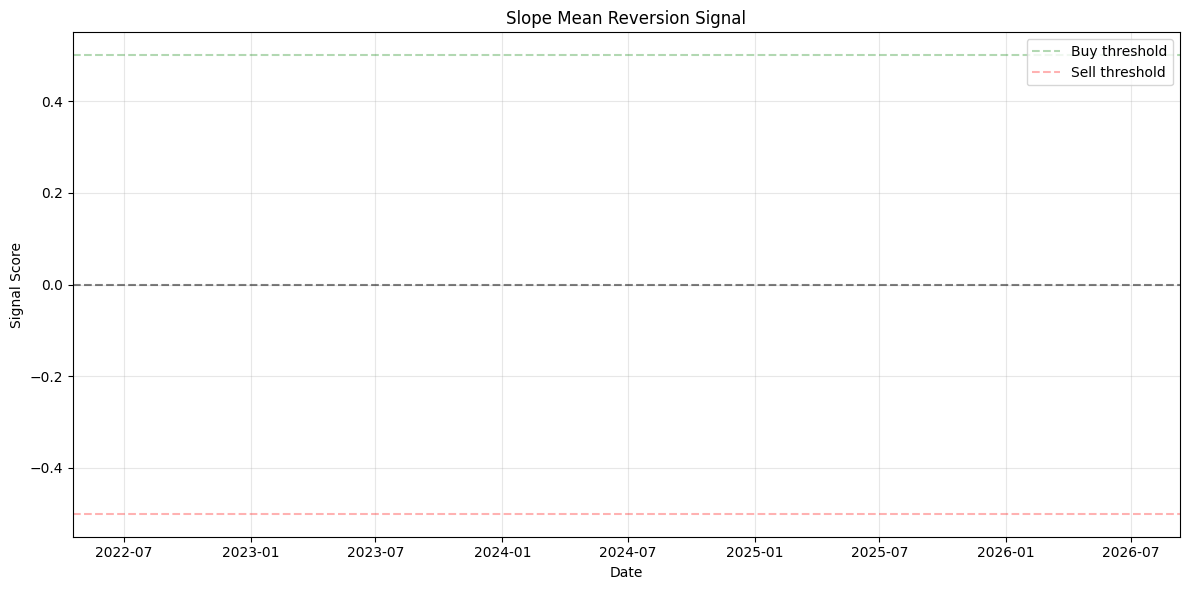


Generated 1 signal observations
Signal range: [0.137, 0.137]
Mean signal: 0.137
Strong signals (|score| > 0.5): 0


In [7]:
# First, convert changes to levels for signal evaluation
# (Signal expects yield levels, not changes)
levels_data = {"date": dates}
for tenor in tenors:
    # Cumulative sum of changes to get levels
    levels_data[tenor] = np.cumsum(changes_df[tenor].to_numpy()) + 3.0  # Start at 3%

levels_df = pl.DataFrame(levels_data)

# Create signal (mean reversion on slope factor)
signal = PCAFactorSignal(
    lookback_days=180,
    target_factor="slope",
    strategy="mean_reversion",
    z_threshold=2.0
)

# Evaluate signal over time (skip first 180 days for lookback)
signal_scores = []
signal_dates = []

for i in range(180, len(dates)):
    try:
        score = signal.evaluate(dates[i], levels_df, tenor_columns=tenors)
        signal_scores.append(score)
        signal_dates.append(dates[i])
    except Exception as e:
        print(f"Error on {dates[i]}: {e}")
        break

# Plot signals
if len(signal_scores) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(signal_dates, signal_scores)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.axhline(y=0.5, color='g', linestyle='--', alpha=0.3, label='Buy threshold')
    plt.axhline(y=-0.5, color='r', linestyle='--', alpha=0.3, label='Sell threshold')
    plt.title("Slope Mean Reversion Signal")
    plt.xlabel("Date")
    plt.ylabel("Signal Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nGenerated {len(signal_scores)} signal observations")
    print(f"Signal range: [{min(signal_scores):.3f}, {max(signal_scores):.3f}]")
    print(f"Mean signal: {np.mean(signal_scores):.3f}")
    print(f"Strong signals (|score| > 0.5): {sum(abs(s) > 0.5 for s in signal_scores)}")

## 7. Factor Statistics

Get summary statistics for all factors.

In [8]:
# Get factor statistics from signal
stats = signal.get_factor_statistics()

if stats:
    print("Factor Statistics:")
    print("=" * 70)
    
    for factor, metrics in stats.items():
        print(f"\n{factor.upper()}:")
        print(f"  Mean: {metrics['mean']:+.4f}")
        print(f"  Std:  {metrics['std']:.4f}")
        print(f"  Min:  {metrics['min']:+.4f}")
        print(f"  Max:  {metrics['max']:+.4f}")
        print(f"  Current: {metrics['current']:+.4f}")
        print(f"  Z-Score: {metrics['z_score']:+.2f}")
        
        if abs(metrics['z_score']) > 2:
            print(f"  ⚠️  EXTREME VALUE (|z| > 2)")

Factor Statistics:

LEVEL:
  Mean: +0.0000
  Std:  0.1522
  Min:  -0.4510
  Max:  +0.4651
  Current: +0.0812
  Z-Score: +0.53

SLOPE:
  Mean: +0.0000
  Std:  0.0522
  Min:  -0.1813
  Max:  +0.1115
  Current: -0.0215
  Z-Score: -0.41

CURVATURE:
  Mean: +0.0000
  Std:  0.0092
  Min:  -0.0257
  Max:  +0.0243
  Current: +0.0116
  Z-Score: +1.26


## Summary

This notebook demonstrated:
1. ✅ PCA factor decomposition of yield curves
2. ✅ Interpreting level/slope/curvature factors
3. ✅ Visualizing factor loadings and time series
4. ✅ Factor-based hedging calculations
5. ✅ Trading signal generation from factor analysis
6. ✅ Factor statistics and extremes detection

**Next Steps**:
- Apply to real yield curve data
- Backtest factor-based strategies
- Compare to traditional DV01 hedging
- Integrate with portfolio optimization